## [Dacon] AI프렌즈 시즌2 강수량 산출 경진대회
## giba.kim (팀명)
## 2020년 5월 29일 (제출날짜)

## Model 1_Kfold4

#### CNN 기반 Custom Model KFold

>* Data: Original Data, -9999 제거 
* Cross Validation: 5 Fold
* Loss: MOFLoss
* Optimizer: RAdam + LARS + LookAHead (https://github.com/mgrankin/over9000)
* Scheduler: CosineAnnealingWarmRestarts(optimizer, 10, 2,eta_min=1e-6)
* Model: CNN 기반 Custom Model
* Batch: 128
* Epoch: 150


## 1. 라이브러리 및 데이터
## Library & Data

In [1]:
from pathlib import Path

smp_dir = Path(r"D:\레인프로젝트\notebooks\segmentation_models_pytorch")

print("폴더 존재:", smp_dir.exists())
print("파일 개수:", len(list(smp_dir.rglob("*.py"))))

for py_file in smp_dir.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8", errors="ignore")
    if "torch._six" in text:
        print("torch._six 남아있는 파일:", py_file)

폴더 존재: True
파일 개수: 47


In [2]:
from pathlib import Path

smp_dir = Path(r"D:\레인프로젝트\notebooks\segmentation_models_pytorch")

patched_files = []

for py_file in smp_dir.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8", errors="ignore")
    old_text = text

    text = text.replace(
        "from torch._six import container_abcs",
        "import collections.abc as container_abcs"
    )

    text = text.replace(
        "from torch._six import string_classes",
        "string_classes = (str,)"
    )

    text = text.replace(
        "from torch._six import int_classes",
        "int_classes = (int,)"
    )

    text = text.replace(
        "from torch._six import inf",
        "from math import inf"
    )

    if text != old_text:
        py_file.write_text(text, encoding="utf-8")
        patched_files.append(str(py_file))

print("패치된 파일 개수:", len(patched_files))

for f in patched_files:
    print("patched:", f)

패치된 파일 개수: 0


In [3]:
from pathlib import Path

smp_dir = Path(r"D:\레인프로젝트\notebooks\segmentation_models_pytorch")

remain = []

for py_file in smp_dir.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8", errors="ignore")
    if "torch._six" in text:
        remain.append(str(py_file))

if len(remain) == 0:
    print("성공: torch._six 전부 제거됨")
else:
    print("아직 남아있음:")
    for f in remain:
        print(f)

성공: torch._six 전부 제거됨


In [4]:
import timm
print(timm.__version__)
print(timm.__file__)

0.4.12
c:\Users\dkfqn\miniconda3\envs\gpu_env\Lib\site-packages\timm\__init__.py


In [5]:
# ===============================
# torch._six + timm Swish 호환성 패치
# 반드시 import segmentation_models_pytorch as smp 보다 먼저 실행
# ===============================

import sys
import types
import math
import torch
import torch.nn as nn
import collections.abc as container_abcs

# 1) torch._six 임시 복구
torch_six = types.ModuleType("torch._six")
torch_six.container_abcs = container_abcs
torch_six.string_classes = (str, bytes)
torch_six.int_classes = (int,)
torch_six.inf = math.inf
sys.modules["torch._six"] = torch_six


# 2) timm Swish 임시 복구
import timm.models.efficientnet as efficientnet

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

efficientnet.Swish = Swish

print("torch._six + timm Swish 패치 완료")


# 3) 그 다음에 smp import
import segmentation_models_pytorch as smp

torch._six + timm Swish 패치 완료


In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import time
import datetime

import glob
import os
import gc
import random
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset as BaseDataset
import torchvision
import torchvision.transforms.functional as TF

from torch import nn
import torch.nn.functional as F
from torch.utils.data import SubsetRandomSampler
from torch.optim import Adam,lr_scheduler,AdamW
from torchvision import transforms,models
from torch.autograd import Variable

import pretrainedmodels
from efficientnet_pytorch import EfficientNet

from torch.optim.optimizer import Optimizer
from collections import defaultdict

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

## Utility Function 정의

#### Optimizer
RAdam + LARS + LookAHead

Lookahead implementation from https://github.com/lonePatient/lookahead_pytorch/blob/master/optimizer.py
RAdam + LARS implementation from https://gist.github.com/redknightlois/c4023d393eb8f92bb44b2ab582d7ec20

In [7]:
from torch.optim.optimizer import Optimizer
from collections import defaultdict, OrderedDict
import math
import torch


class Lookahead(Optimizer):
    def __init__(self, base_optimizer, alpha=0.5, k=6):
        if not 0.0 <= alpha <= 1.0:
            raise ValueError(f'Invalid slow update rate: {alpha}')
        if not 1 <= k:
            raise ValueError(f'Invalid lookahead steps: {k}')
        defaults = dict(lookahead_alpha=alpha, lookahead_k=k, lookahead_step=0)
        self.base_optimizer = base_optimizer
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = base_optimizer.defaults
        self.defaults.update(defaults)
        self.state = defaultdict(dict)

        # 최신 PyTorch Optimizer 호환용 hook 속성 추가
        self._optimizer_step_pre_hooks = OrderedDict()
        self._optimizer_step_post_hooks = OrderedDict()
        self._optimizer_state_dict_pre_hooks = OrderedDict()
        self._optimizer_state_dict_post_hooks = OrderedDict()
        self._optimizer_load_state_dict_pre_hooks = OrderedDict()
        self._optimizer_load_state_dict_post_hooks = OrderedDict()
        self._optimizer_state_dict_pre_hooks = OrderedDict()
        self._optimizer_state_dict_post_hooks = OrderedDict()
        self._optimizer_load_state_dict_pre_hooks = OrderedDict()
        self._optimizer_load_state_dict_post_hooks = OrderedDict()

        # manually add our defaults to the param groups
        for name, default in defaults.items():
            for group in self.param_groups:
                group.setdefault(name, default)
                

    def update_slow(self, group):
        for fast_p in group["params"]:
            if fast_p.grad is None:
                continue
            param_state = self.state[fast_p]
            if 'slow_buffer' not in param_state:
                param_state['slow_buffer'] = torch.empty_like(fast_p.data)
                param_state['slow_buffer'].copy_(fast_p.data)
            slow = param_state['slow_buffer']
            slow.add_(group['lookahead_alpha'], fast_p.data - slow)
            fast_p.data.copy_(slow)

    def sync_lookahead(self):
        for group in self.param_groups:
            self.update_slow(group)

    def step(self, closure=None):
        # print(self.k)
        #assert id(self.param_groups) == id(self.base_optimizer.param_groups)
        loss = self.base_optimizer.step(closure)
        for group in self.param_groups:
            group['lookahead_step'] += 1
            if group['lookahead_step'] % group['lookahead_k'] == 0:
                self.update_slow(group)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        fast_state_dict = self.base_optimizer.state_dict()
        slow_state = {
            (id(k) if isinstance(k, torch.Tensor) else k): v
            for k, v in self.state.items()
        }
        fast_state = fast_state_dict['state']
        param_groups = fast_state_dict['param_groups']
        return {
            'state': fast_state,
            'slow_state': slow_state,
            'param_groups': param_groups,
        }

    def load_state_dict(self, state_dict):
        fast_state_dict = {
            'state': state_dict['state'],
            'param_groups': state_dict['param_groups'],
        }
        self.base_optimizer.load_state_dict(fast_state_dict)

        # We want to restore the slow state, but share param_groups reference
        # with base_optimizer. This is a bit redundant but least code
        slow_state_new = False
        if 'slow_state' not in state_dict:
            print('Loading state_dict from optimizer without Lookahead applied.')
            state_dict['slow_state'] = defaultdict(dict)
            slow_state_new = True
        slow_state_dict = {
            'state': state_dict['slow_state'],
            'param_groups': state_dict['param_groups'],  # this is pointless but saves code
        }
        super(Lookahead, self).load_state_dict(slow_state_dict)
        self.param_groups = self.base_optimizer.param_groups  # make both ref same container
        if slow_state_new:
            # reapply defaults to catch missing lookahead specific ones
            for name, default in self.defaults.items():
                for group in self.param_groups:
                    group.setdefault(name, default)
                    

class Ralamb(Optimizer):

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        self.buffer = [[None, None, None] for ind in range(10)]
        super(Ralamb, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(Ralamb, self).__setstate__(state)

    def step(self, closure=None):

        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data.float()
                if grad.is_sparse:
                    raise RuntimeError('Ralamb does not support sparse gradients')

                p_data_fp32 = p.data.float()

                state = self.state[p]

                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p_data_fp32)
                    state['exp_avg_sq'] = torch.zeros_like(p_data_fp32)
                else:
                    state['exp_avg'] = state['exp_avg'].type_as(p_data_fp32)
                    state['exp_avg_sq'] = state['exp_avg_sq'].type_as(p_data_fp32)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']

                # Decay the first and second moment running average coefficient
                # m_t
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                # v_t
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                state['step'] += 1
                buffered = self.buffer[int(state['step'] % 10)]

                if state['step'] == buffered[0]:
                    N_sma, radam_step_size = buffered[1], buffered[2]
                else:
                    buffered[0] = state['step']
                    beta2_t = beta2 ** state['step']
                    N_sma_max = 2 / (1 - beta2) - 1
                    N_sma = N_sma_max - 2 * state['step'] * beta2_t / (1 - beta2_t)
                    buffered[1] = N_sma

                    # more conservative since it's an approximated value
                    if N_sma >= 5:
                        radam_step_size = math.sqrt(
                            (1 - beta2_t) *
                            (N_sma - 4) / (N_sma_max - 4) *
                            (N_sma - 2) / N_sma *
                            N_sma_max / (N_sma_max - 2)
                        ) / (1 - beta1 ** state['step'])
                    else:
                        radam_step_size = 1.0 / (1 - beta1 ** state['step'])
                    buffered[2] = radam_step_size

                if group['weight_decay'] != 0:
                    p_data_fp32.add_(p_data_fp32, alpha=-group['weight_decay'] * group['lr'])

                # more conservative since it's an approximated value
                radam_step = p_data_fp32.clone()
                if N_sma >= 5:
                    denom = exp_avg_sq.sqrt().add_(group['eps'])
                    radam_step.addcdiv_(exp_avg, denom, value=-radam_step_size * group['lr'])
                else:
                    radam_step.add_(exp_avg, alpha=-radam_step_size * group['lr'])

                radam_norm = radam_step.pow(2).sum().sqrt()
                weight_norm = p.data.pow(2).sum().sqrt().clamp(0, 10)
                if weight_norm == 0 or radam_norm == 0:
                    trust_ratio = 1
                else:
                    trust_ratio = weight_norm / radam_norm

                state['weight_norm'] = weight_norm
                state['adam_norm'] = radam_norm
                state['trust_ratio'] = trust_ratio

                if N_sma >= 5:
                    p_data_fp32.addcdiv_(
                        exp_avg,
                        denom,
                        value=-radam_step_size * group['lr'] * trust_ratio
                    )
                else:
                    p_data_fp32.add_(
                        exp_avg,
                        alpha=-radam_step_size * group['lr'] * trust_ratio
                    )

                p.data.copy_(p_data_fp32)

        return loss

#### 대회 Metric Code

In [8]:
from sklearn.metrics import f1_score

def mae(y_true, y_pred) :
    
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    y_true = y_true.reshape(1, -1)[0]
    
    y_pred = y_pred.reshape(1, -1)[0]
    
    over_threshold = y_true >= 0.1
    
    return np.mean(np.abs(y_true[over_threshold] - y_pred[over_threshold]))

def fscore(y_true, y_pred):
    
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    y_true = y_true.reshape(1, -1)[0]
    
    y_pred = y_pred.reshape(1, -1)[0]
    
    remove_NAs = y_true >= 0
    
    y_true = np.where(y_true[remove_NAs] >= 0.1, 1, 0)
    
    y_pred = np.where(y_pred[remove_NAs] >= 0.1, 1, 0)
    
    return(f1_score(y_true, y_pred))

def maeOverFscore(y_true, y_pred):
    _fs = fscore(y_true, y_pred)
    _mae = mae(y_true, y_pred)
    print("F-Score: ", _fs)
    print("MAE: ", _mae)
    return _mae / (_fs + 1e-07)

#### Seed Fixed

In [9]:
# seed value fix
# seed 값을 고정해야 hyper parameter 바꿀 때마다 결과를 비교할 수 있습니다.
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 0
seed_everything(SEED)

#### Dataset 정의

In [10]:
class Dataset(BaseDataset):
    def __init__(self, train_files, is_test_or_not=False, is_transform=False, aug_ratio=0):
        """
        train_files: train file list
        is_test_or_not: test or not
        is_transform: True augmentation
        aug_ratio: augmentation ratio
        """
        self.train_files = train_files
        self.is_test_or_not=is_test_or_not
        self.is_transform = is_transform
        self.aug_ratio = aug_ratio
    
    # data augmenation 6개
    # rot90, rot180, rot270, vflip, hflip, transpose
    def aug_flip(self, feature, target):
        switch = np.random.choice(6) # random 선택
        if switch==0: # rot90
            feature_aug=np.rot90(feature,k=1,axes=[1,2]).copy()
            target_aug=np.rot90(target,k=1,axes=[1,2]).copy()  
        elif switch==1: # rot180
            feature_aug=np.rot90(feature,k=2,axes=[1,2]).copy()
            target_aug=np.rot90(target,k=2,axes=[1,2]).copy()
        elif switch==2:  # rot270
            feature_aug=np.rot90(feature,k=3,axes=[1,2]).copy()
            target_aug=np.rot90(target,k=3,axes=[1,2]).copy()
        elif switch==3:  # vflip
            feature_aug=np.flip(feature,axis=[1]).copy()
            target_aug=np.flip(target,axis=[1]).copy()
        elif switch==4:  # hflip
            feature_aug=np.flip(feature,axis=[2]).copy()
            target_aug=np.flip(target,axis=[2]).copy()
        elif switch==5:  # transpose
            feature_aug=np.transpose(feature,[0,2,1]).copy()
            target_aug=np.transpose(target,[0,2,1]).copy()

        return feature_aug, target_aug

    def augmetation(self, feature, target):
        # uniform한 확률분포를 가져와서 지정된 aug_ratio보다 작으면 augmentation을 하지 않습니다.
        aug_prop = np.random.uniform()
        is_aug = aug_prop <= self.aug_ratio
        if not is_aug:
            return feature, target
        
        feature_aug, target_aug = self.aug_flip(feature, target)
            
        return feature_aug, target_aug

    def __getitem__(self, i):
        try:
            dataset = np.load(self.train_files[i]) 
        except:
            dataset = np.load(self.train_files[i].replace('\\','/')) 
        
        if isinstance(dataset, np.lib.npyio.NpzFile):
            dataset = dataset[dataset.files[0]]
        
        # target 값 정의
        target= np.moveaxis(dataset[:,:,-1].reshape(40,40,1),-1,0).astype(np.float32)
        
        # train일 때 target값은 제외하고 전처리 수행하기 위해서
        if not self.is_test_or_not:
            dataset = dataset[:,:,:-1]
        
        # GMI, DPR의 위/경도 diff
        dataset[:,:,10] = dataset[:,:,10] - dataset[:,:,12]
        dataset[:,:,11] = dataset[:,:,11] - dataset[:,:,13]
        
        # StandardScaling
        norm_temp = (dataset[:,:,:12]-mean_vector[None,None,:12])/std_vector[None,None,:12]
        feature = np.moveaxis(norm_temp,-1,0).astype(np.float32)
        
        # test와 augmentation을 하지 않을 경우 그대로 image와 target return
        if self.is_test_or_not or not self.is_transform:
            return feature, target
        
        # augmentation 수행하고 return
        return self.augmetation(feature, target)
        
    def __len__(self):
        return len(self.train_files)

validset batch size를 2로하면 mae_over_fscore가 계산이 잘 안되는 문제가 있어 validset 전체에 대하여 Metric을 계산하는 Utility Function

In [11]:
def get_mof_valid(nn_model, valid_loader):
    print("Valid All MOF")
    nn_model.eval()
    val_results = []
    val_targets = []
    for batch_idx, (feature, target) in enumerate(valid_loader):
        feature_copy = copy.deepcopy(feature)
        target_copy = copy.deepcopy(target)
        val_results.append(nn_model.predict(feature_copy.cuda()).view(-1,1600).cpu().numpy())
        val_targets.append(target_copy.view(-1,1600).cpu().numpy())
        del feature
        del target
    mof = maeOverFscore(np.concatenate(val_targets),np.concatenate(val_results))
    print(mof)
    return mof

## 2. 데이터 전처리
## Data Cleansing & Pre-Processing  

1. train feature파일을 load하여 강수량이 0보다 큰 것만 선택합니다. (-9999 제외)
2. GMI와 DPR의 위/경도 차이를 계산합니다.
3. Dataset에서 StandardScale을 하기 위해 mean_vector와 std_vector를 계산합니다.

In [12]:
train_df = pd.read_feather('../input/train.ftr')
train_df = train_df.loc[train_df['precipitation']>=0].reset_index(drop=True)

train_df['long_GMI'] = train_df['long_GMI'] - train_df['long_DPR']
train_df['lat_GMI'] = train_df['lat_GMI'] - train_df['lat_DPR']

train_columns = [c for c in train_df.columns if c not in ['precipitation', 'orbit', 'subset', 'pixel']]
mean_vector = []
std_vector = []
for c in train_columns:
    train_df[c] = train_df[c].astype(np.float32)
    _m = train_df[c].mean()
    mean_vector.append(_m)
    _s = train_df[c].std()
    std_vector.append(_s)
mean_vector = np.array(mean_vector)
std_vector = np.array(std_vector)

## 5. 모델 학습 및 검증
## Model Tuning & Evaluation

In [13]:
class SimpleConv(nn.Module):
    def __init__(self,):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(12)
        self.conv0 =  nn.Conv2d(12, 64, kernel_size=1, stride=1, bias=False)
        self.bn_128 = nn.BatchNorm2d(64)

        self.conv1_1 =  nn.Conv2d(64, 32, kernel_size=1, stride=1, bias=False)
        self.conv1_2 =  nn.Conv2d(64, 32, kernel_size=3, stride=1, bias=False, padding=1)
        self.conv1_3 =  nn.Conv2d(64, 32, kernel_size=5, stride=1, bias=False, padding=2)

        self.conv2_1 =  nn.Conv2d(64, 32, kernel_size=7, stride=1, bias=False, padding=3)
        self.conv2_2 =  nn.Conv2d(64, 32, kernel_size=9, stride=1, bias=False, padding=4)
        self.conv2_3 =  nn.Conv2d(64, 32, kernel_size=11, stride=1, bias=False, padding=5)

        self.bn_concat = nn.BatchNorm2d(64+(32+32+32)*2)

        self.bottle_1 = nn.Conv2d(64+(32+32+32)*2,128,kernel_size=1, stride=1, bias=False)
        self.bottle_2 = nn.Conv2d(128,64, kernel_size=3, stride=1, bias=False, padding=1)

        self.bottle_3 = nn.Conv2d(64+(32+32+32)*2,128,kernel_size=3, stride=1, bias=False, padding=1)
        self.bottle_4 = nn.Conv2d(128, 64, kernel_size=1, stride=1, bias=False)

        self.bn_bottleneck24 = nn.BatchNorm2d(64+(32+32+32)*2+64+64)

        self.bottle_5 = nn.Conv2d(64+(32+32+32)*2+64+64,256,kernel_size=1, stride=1, bias=False)
        self.bottle_6 = nn.Conv2d(256,128,kernel_size=3, stride=1, bias=False, padding=1)

        self.bn_output = nn.BatchNorm2d(128)
        self.conv_out = nn.Conv2d(128, 1, kernel_size=1, stride=1, bias=False)
        self.relu =  nn.ReLU()


    def forward(self, inputs):

        x = self.bn0(inputs)
        conv0 = self.conv0(x)
        conv0 = self.bn_128(conv0)
        conv0 = self.relu(conv0)

        conv1_1 = self.conv1_1(conv0)
        conv1_2 = self.conv1_2(conv0)
        conv1_3 = self.conv1_3(conv0)

        conv2_1 = self.conv2_1(conv0)
        conv2_2 = self.conv2_2(conv0)
        conv2_3 = self.conv2_3(conv0)

        concat = torch.cat([conv0, 
                            conv1_1, conv1_2, conv1_3, 
                            conv2_1, conv2_2, conv2_3
                            ],axis=1)

        concat = self.relu(concat)
        bn_concat = self.bn_concat(concat)

        bottle_1 = self.bottle_1(bn_concat)
        bottle_1 = self.relu(bottle_1)
        bottle_2 = self.bottle_2(bottle_1)
        bottle_2 = self.relu(bottle_2)

        bottle_3 = self.bottle_3(bn_concat)
        bottle_3 = self.relu(bottle_3)
        bottle_4 = self.bottle_4(bottle_3)
        bottle_4 = self.relu(bottle_4)

        bottle24_concat = torch.cat([bn_concat, bottle_2, bottle_4],axis=1)
        bottle24_concat = self.bn_bottleneck24(bottle24_concat)

        bottle_5 = self.bottle_5(bottle24_concat)
        bottle_5 = self.relu(bottle_5)
        bottle_6 = self.bottle_6(bottle_5)
        bottle_6 = self.relu(bottle_6)

        conv_out = self.bn_output(bottle_6)
        out = self.conv_out(conv_out)
        out = self.relu(out)

        return out 

    def predict(self, x):
        if self.training:
            print('get eval')
            self.eval()

        with torch.no_grad():
            x = self.forward(x)

        return x

#### Model, Loss, Metrics, optimizer, scheduler 정의

In [14]:
model = SimpleConv()

# MOFLoss란 mae_over_fscore의 줄인말로 계산 방식은 동일합니다.
# pytorch로 구현되었습니다.
loss = smp.utils.losses.MOFLoss()

# 마찬가지로 mae_over_fscore의 pytorch metric version입니다.
metrics = [ smp.utils.metrics.MAEOVERFSCORE()]

base_optimizer = Ralamb(model.parameters(), weight_decay=0.01)
optimizer = Lookahead(base_optimizer)

scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer, 10, 2,eta_min=1e-6) # 1e-6

#### 학습을 도와주는 Epoch Module에 Model, loss, metrics, optimizer를 넣고 epoch 객체 생성

In [15]:
DEVICE = 'cuda'
train_epoch = smp.utils.train.TrainEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)

valid_epoch = smp.utils.train.ValidEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    device=DEVICE,
    verbose=True,
)

#### Dataset에 전달할 train file list와 valid file list를 만드는 코드입니다.
1. 기존에 저장된 file이 있다면 pickle library를 사용하여 load하고 없다면 새로 만듭니다.
2. train path를 정의합니다. train_path = '../input/train'
2. CrossValidation을 하기 때문에 따로 Validationd을 두지 않습니다.
3. train 데이터는 target값에 0보다 작은 값이 하나라도 있으면 사용하지 않습니다.

In [16]:
import pickle

TRAIN_FILE = 'train_files_rmna_kfold'
if os.path.exists(TRAIN_FILE):
    train_files_rmna=pickle.load(open(TRAIN_FILE,'rb'))
else:
    print("Make file")
    train_path = '../input/train/'
    train_files = sorted(glob.glob(train_path + '/*'))
    train_files = [file.replace('\\','/') for file in train_files]
    
    train_files_rmna = []
    for file in tqdm(train_files):
        dataset = np.load(file)
        target= np.moveaxis(dataset[:,:,-1].reshape(40,40,1),-1,0).astype(np.float32)
        if np.sum(target <0) == 0:
            train_files_rmna.append(file)
    
    pickle.dump(train_files_rmna,open(TRAIN_FILE,'wb'))
    
    print(len(train_files_rmna))

In [17]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
import numpy as np
import os
import torch

# 저장 폴더 없으면 생성
os.makedirs("best_model", exist_ok=True)

train_files_rmna = np.array(train_files_rmna)

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

# 여기서 4번, 5번 fold만 학습
target_fold_indices = [5]

for fold_index, (trn_idx, val_idx) in enumerate(kfold.split(train_files_rmna), 1):

    if fold_index not in target_fold_indices:
        continue

    print("=" * 50)
    print(f"{fold_index} FOLD START")
    print("=" * 50)

    trn_file = train_files_rmna[trn_idx]
    val_file = train_files_rmna[val_idx]

    print("Train files:", len(trn_file))
    print("Valid files:", len(val_file))

    # Dataset
    train_dataset = Dataset(
        trn_file,
        is_test_or_not=False,
        is_transform=True,
        aug_ratio=0.5
    )

    valid_dataset = Dataset(
        val_file,
        is_test_or_not=False,
        is_transform=False
    )

    # DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=2,
        shuffle=False,
        num_workers=0
    )

    # Model
    model = SimpleConv()

    loss = smp.utils.losses.MOFLoss()
    metrics = [smp.utils.metrics.MAEOVERFSCORE()]

    base_optimizer = Ralamb(model.parameters(), weight_decay=0.01)
    optimizer = Lookahead(base_optimizer)

    scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    train_epoch = smp.utils.train.TrainEpoch(
        model,
        loss=loss,
        metrics=metrics,
        optimizer=optimizer,
        device=DEVICE,
        verbose=True
    )

    valid_epoch = smp.utils.train.ValidEpoch(
        model,
        loss=loss,
        metrics=metrics,
        device=DEVICE,
        verbose=True
    )

    NUM_EPOCH = 3
    min_score = np.inf
    MODEL = "SimpleConv"

    for epoch in range(NUM_EPOCH):
        print(f"\nFold {fold_index} / Epoch {epoch}")

        train_logs = train_epoch.run(train_loader)

        # validation score 계산
        mof = get_mof_valid(model, valid_loader)

        scheduler.step()

        print(f"Validation MOF: {mof}")

        if min_score > mof:
            min_score = mof

            # 점수 포함 저장
            torch.save(
                model,
                f"best_model/{fold_index}_{MODEL}_{loss.__name__}_{mof}_epoch_{epoch}.pth"
            )

            # 최종 best 이름으로도 저장
            torch.save(
                model,
                f"best_model/{fold_index}_{MODEL}_{loss.__name__}.pth"
            )

            print(f"Model saved! Fold {fold_index}, Best MOF: {min_score}")

    print(f"{fold_index} FOLD FINISHED")
    print(f"Best MOF of Fold {fold_index}: {min_score}")

5 FOLD START
Train files: 60767
Valid files: 15191

Fold 5 / Epoch 0
train:   1%|▏         | 6/475 [00:08<09:50,  1.26s/it, mof_loss - 4.431, maeoverfscore - 4.431]

C:\Users\dkfqn\AppData\Local\Temp\ipykernel_31900\1546634444.py:47: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1853.)
  slow.add_(group['lookahead_alpha'], fast_p.data - slow)


train: 100%|██████████| 475/475 [09:00<00:00,  1.14s/it, mof_loss - 2.122, maeoverfscore - 2.122]
Valid All MOF


NameError: name 'copy' is not defined

In [18]:
import glob
import os

files = glob.glob("best_model/4_*.pth")

for f in files:
    print(os.path.basename(f))

4_SimpleConv_mof_loss.pth
4_SimpleConv_mof_loss_1.8355131149291992_epoch_1.pth
4_SimpleConv_mof_loss_1.9355525970458984_epoch_0.pth


In [19]:
import os

print(os.listdir(r"D:\레인프로젝트\notebooks\best_model"))

['1_SimpleConv_L1Loss.pth', '1_SimpleConv_L1Loss_9.71875286102295_epoch_0.pth', '1_SimpleConv_mof_loss.pth', '1_SimpleConv_mof_loss_1.8167145252227783_epoch_1.pth', '1_SimpleConv_mof_loss_1.9762485027313232_epoch_0.pth', '1_SimpleConv_mof_loss_2.030916213989258_epoch_0.pth', '2_SimpleConv_mof_loss.pth', '2_SimpleConv_mof_loss_1.7227308750152588_epoch_2.pth', '2_SimpleConv_mof_loss_1.8193882703781128_epoch_1.pth', '2_SimpleConv_mof_loss_1.853900671005249_epoch_0.pth', '3_SimpleConv_mof_loss.pth', '3_SimpleConv_mof_loss_1.7247127294540405_epoch_2.pth', '3_SimpleConv_mof_loss_1.9402179718017578_epoch_1.pth', '3_SimpleConv_mof_loss_1.951340675354004_epoch_0.pth', '4_SimpleConv_mof_loss.pth', '4_SimpleConv_mof_loss_1.8355131149291992_epoch_1.pth', '4_SimpleConv_mof_loss_1.9355525970458984_epoch_0.pth', '5_SimpleConv_mof_loss.pth', '5_SimpleConv_mof_loss_1.7570782899856567_epoch_2.pth', '5_SimpleConv_mof_loss_1.8447390794754028_epoch_1.pth', '5_SimpleConv_mof_loss_1.8978687524795532_epoch_0.

In [20]:
model_paths = [
    r"D:\레인프로젝트\notebooks\best_model\fold1.pth",
    r"D:\레인프로젝트\notebooks\best_model\fold2.pth",
    r"D:\레인프로젝트\notebooks\best_model\fold3.pth",
    r"D:\레인프로젝트\notebooks\best_model\fold4.pth",
    r"D:\레인프로젝트\notebooks\best_model\fold5.pth",
]

In [21]:
import os

model_dir = r"D:\레인프로젝트\notebooks\best_model"

model_paths = [
    os.path.join(model_dir, "1_SimpleConv_mof_loss.pth"),
    os.path.join(model_dir, "2_SimpleConv_mof_loss.pth"),
    os.path.join(model_dir, "3_SimpleConv_mof_loss.pth"),
    os.path.join(model_dir, "4_SimpleConv_mof_loss.pth"),
    os.path.join(model_dir, "5_SimpleConv_mof_loss.pth"),
]

for path in model_paths:
    print(path, os.path.exists(path))

D:\레인프로젝트\notebooks\best_model\1_SimpleConv_mof_loss.pth True
D:\레인프로젝트\notebooks\best_model\2_SimpleConv_mof_loss.pth True
D:\레인프로젝트\notebooks\best_model\3_SimpleConv_mof_loss.pth True
D:\레인프로젝트\notebooks\best_model\4_SimpleConv_mof_loss.pth True
D:\레인프로젝트\notebooks\best_model\5_SimpleConv_mof_loss.pth True


In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

models = []

for path in model_paths:
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    # 1. 모델 전체가 저장된 경우: torch.save(model, path)
    if isinstance(checkpoint, torch.nn.Module):
        model = checkpoint

    # 2. dict 형태로 저장된 경우
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model = SimpleConv()
        model.load_state_dict(checkpoint["model_state_dict"])

    # 3. 순수 state_dict로 저장된 경우
    elif isinstance(checkpoint, dict):
        model = SimpleConv()
        model.load_state_dict(checkpoint)

    else:
        raise TypeError(f"알 수 없는 checkpoint 타입: {type(checkpoint)}")

    model.to(device)
    model.eval()
    models.append(model)

print(f"{len(models)}개 모델 로드 완료")

5개 모델 로드 완료


In [23]:
def visualize_ensemble_prediction(models, dataset, idx=0, device="cuda"):
    feature, target = dataset[idx]

    if isinstance(feature, np.ndarray):
        x = torch.tensor(feature).float().unsqueeze(0)
    else:
        x = feature.float().unsqueeze(0)

    ensemble_pred = ensemble_predict(models, x, device=device)
    pred = ensemble_pred.squeeze()

    if isinstance(target, torch.Tensor):
        target = target.detach().cpu().numpy()
    target = target.squeeze()

    error = np.abs(target - pred)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(target, cmap="Blues")
    plt.colorbar()
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred, cmap="Blues")
    plt.colorbar()
    plt.title("Ensemble Prediction")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(error, cmap="Reds")
    plt.colorbar()
    plt.title("Absolute Error")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [24]:
def ensemble_predict(models, x, device="cuda"):
    preds = []

    x = x.to(device)

    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(x)

        preds.append(pred.detach().cpu().numpy())

    ensemble_pred = np.mean(preds, axis=0)
    return ensemble_pred

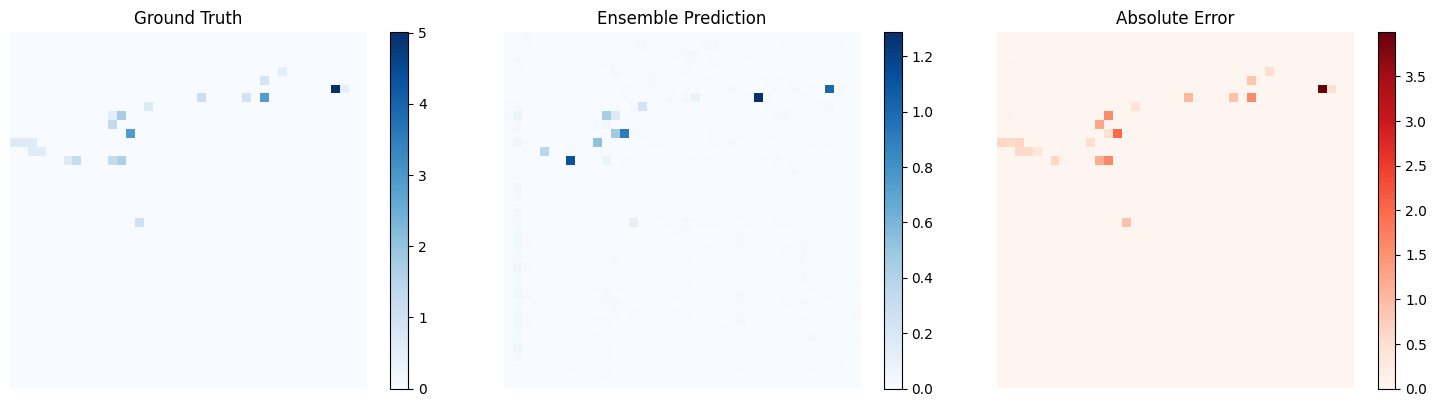

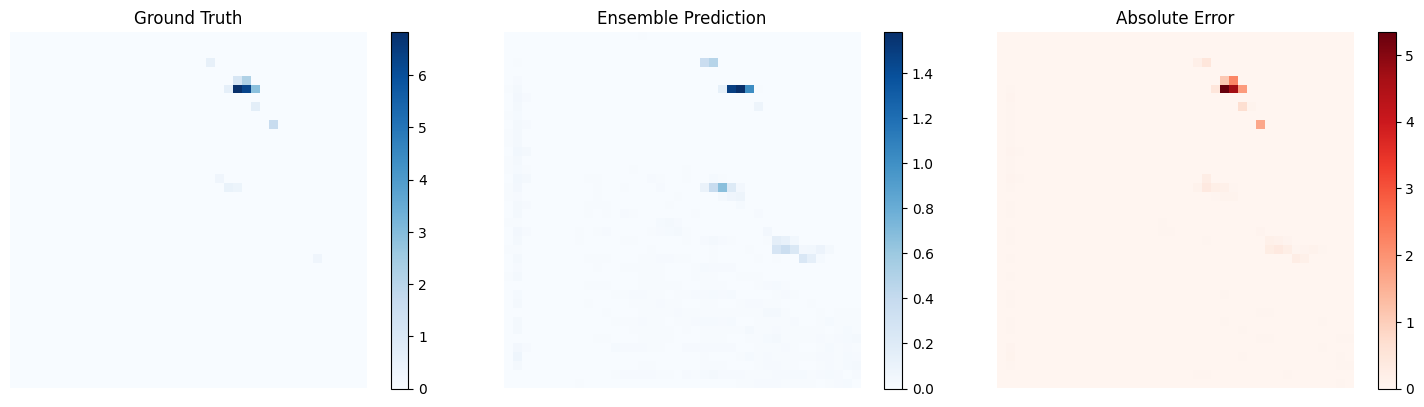

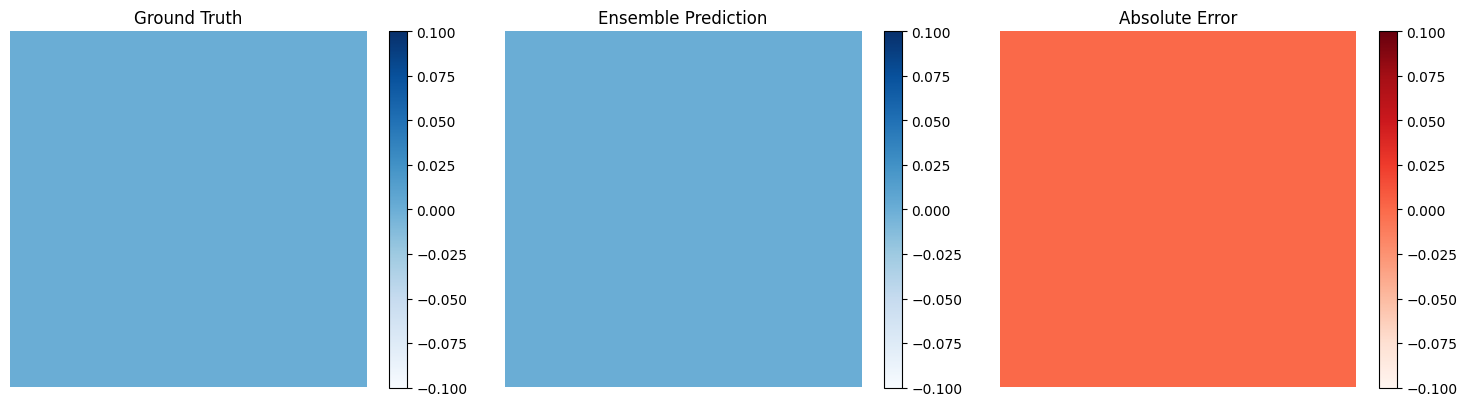

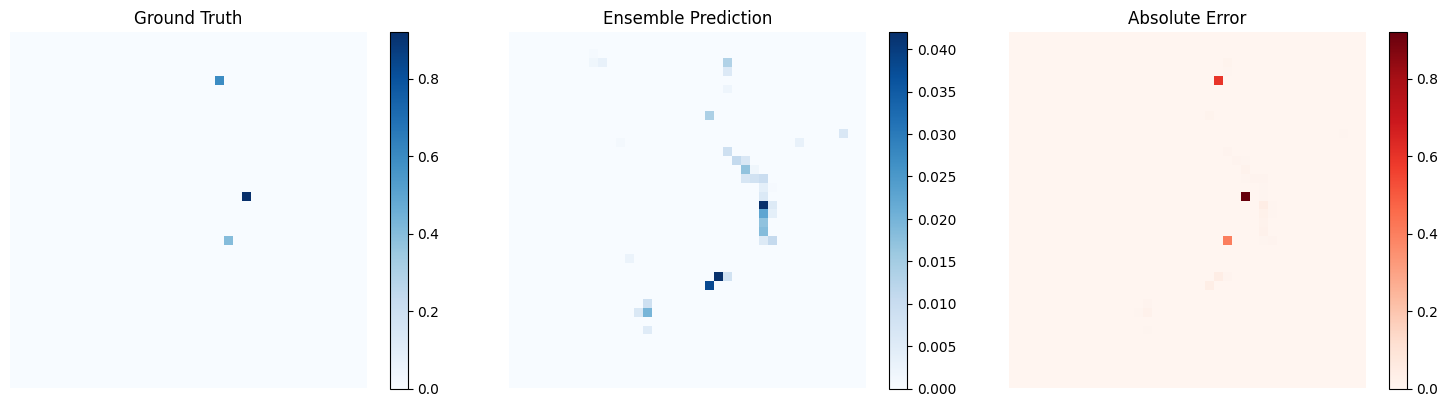

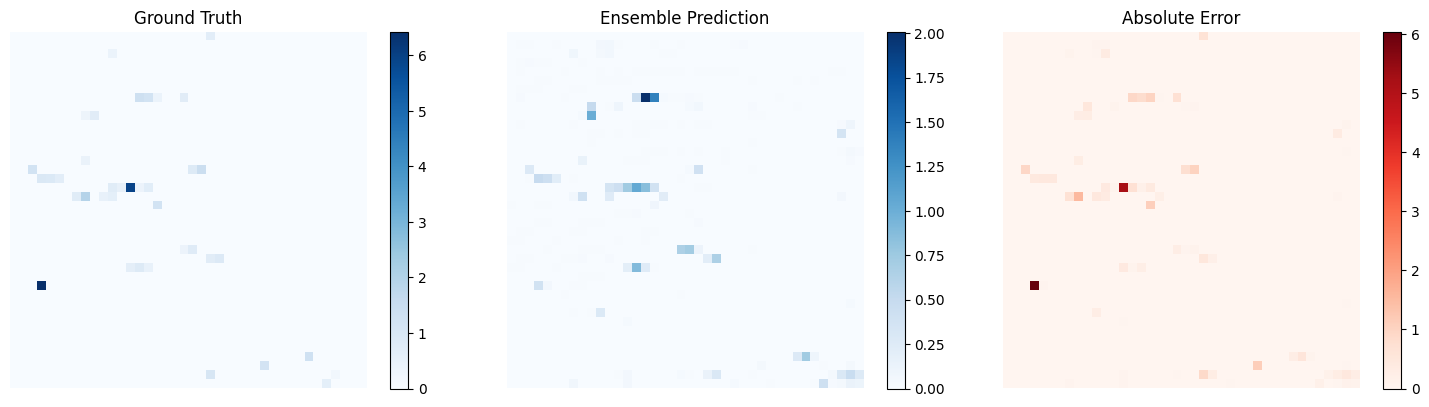

In [25]:
for idx in [0, 5, 10, 20, 30]:
    visualize_ensemble_prediction(models, valid_dataset, idx=idx, device=device)

In [ ]:
## 6. 5-Fold 학습 결과 요약

각 Fold에서 저장된 Best MOF Loss를 비교하고 전체 평균과 표준편차를 확인한다.  
MOF Loss는 낮을수록 성능이 좋다.

In [26]:
# 5-Fold Best Validation MOF 결과 정리

fold_scores = {
    "Fold 1": 1.8167145252227783,
    "Fold 2": 1.7227308750152588,
    "Fold 3": 1.7247127294540405,
    "Fold 4": 1.8355131149291992,
    "Fold 5": 1.7570782899856567
}

score_df = pd.DataFrame(
    fold_scores.items(),
    columns=["Fold", "Best MOF Loss"]
)

display(score_df)

mean_score = score_df["Best MOF Loss"].mean()
std_score = score_df["Best MOF Loss"].std()
best_fold = score_df.loc[
    score_df["Best MOF Loss"].idxmin()
]

print(f"5-Fold 평균 MOF Loss: {mean_score:.4f}")
print(f"5-Fold 표준편차: {std_score:.4f}")
print(
    f"가장 좋은 Fold: {best_fold['Fold']} "
    f"({best_fold['Best MOF Loss']:.4f})"
)

,Fold,Best MOF Loss
0,Fold 1,1.816715
1,Fold 2,1.722731
2,Fold 3,1.724713
3,Fold 4,1.835513
4,Fold 5,1.757078


5-Fold 평균 MOF Loss: 1.7713
5-Fold 표준편차: 0.0522
가장 좋은 Fold: Fold 2 (1.7227)
